In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from dialysisml import config
from dialysisml.pipeline.run_steps import build_hydra_cfg, run_fitted, run_unfitted, x_y_split, split_frame
from sksurv.nonparametric import kaplan_meier_estimator
import matplotlib.pyplot as plt
from dialysisml.adapters import XGBoostAdapter, ModelAdapter, FFNNAdapter
from dialysisml.config import SAVED_ADAPTERS
import numpy as np
import mlflow
import mlflow.artifacts
import time
from dialysisml.adapters import FFNNAdapter
from dialysisml.conf.schemas import Config

mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)

/home/vincenzo/Desktop/Bachelor/Internship/DialysisML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## load runs

In [2]:
formulations = ["buckets", "first_event_cap365"]


confs : list[tuple[Config, pd.DataFrame]] = []
for formulation in formulations:
    exp = mlflow.search_experiments(filter_string=f"name='{formulation}'")[0]
    runs = mlflow.search_runs([exp.experiment_id])
    cfg = build_hydra_cfg({"formulation":f"{formulation}/_base"})
    confs.append((cfg, runs))


    runs = runs[runs["tags.adapter"].notna()]


## Compute KM over triage


In [3]:




def survival_at(times, survival, day):
    idx = np.searchsorted(times, day, side="right") - 1
    return 1.0 if idx < 0 else survival[idx]

def emp_probs(tte_pred : np.ndarray, threshold : float | None = None):
    lo, hi = 180, 365
    # triage boolean masks
    reds = tte_pred <= lo
    yellows = (lo < tte_pred) & (tte_pred < hi)
    greens = tte_pred >= hi

    n_reds, n_yellows, n_greens = reds.sum(), yellows.sum(), greens.sum()
    if n_reds == 0 or n_greens == 0:
        return None

    # compute km for each triage group
    red_times, km_reds = kaplan_meier_estimator(event[reds], time_exit[reds])  # type:ignore
    green_times, km_greens = kaplan_meier_estimator(event[greens], time_exit[greens])  # type:ignore

    Pr = survival_at(red_times, km_reds, 180)  # empirical prob. to have TTE > 180
    Pg = survival_at(green_times, km_greens, 365)  # empirical prob. to have TTE > 365
    Bg = 1 - Pg  # empirical prob. to have TTE <= 365

    res = {
            "run_id": run_id,
            "threshold": threshold,
            "n_reds": n_reds,
            "n_yellows": n_yellows,
            "n_greens": n_greens,
            "Pr": Pr,
            "Pg": Pg,
            "Bg": Bg,
        }
    return res

records = []
for cfg, runs in confs:
    frame = run_unfitted(cfg)
    train, test = split_frame(cfg, frame)
    train, test = run_fitted(cfg, train, test)
    df = test.data

    event = ~df["censored"].to_numpy(dtype=bool)
    time_exit = df["tte"].to_numpy(dtype=np.int32)

    X_test, _ = x_y_split(cfg, test)

    for idx, run in runs.iterrows():
        run_id = str(run["run_id"])


        estimator = ModelAdapter.create(run["tags.adapter"])
        estimator = estimator.load(SAVED_ADAPTERS / run_id)
        if isinstance(estimator, XGBoostAdapter):
            surv_probs = estimator.survival(X_test)
            # test different thresholds
            for threshold in np.arange(0.1, 1, 0.05):
                tte_pred = estimator.predict(X_test, threshold, surv_probs) * 30
                record = emp_probs(tte_pred, threshold)
                if record:
                    record.update({"params": estimator.dump_params(), "Model":"XGBClassifier"})
                    records.append(record)
        elif isinstance(estimator, FFNNAdapter):
            tte_pred = estimator.predict(X_test)* 30
            record = emp_probs(tte_pred)
            if record:
                record.update({"params": estimator.dump_params(), "Model":"FFNN"})
                records.append(record)
        else:
            print(f"{estimator} not supported.")
    
    
results = pd.DataFrame.from_records(records)
results = results[results["Model"] == "XGBClassifier"]


## Plot results

,run_id,threshold,n_reds,n_yellows,n_greens,Pr,Pg,Bg
223,8ffa42c8969f4491ab3090e3fb879c5a,0.20,327,1363,146605,0.000000,0.744554,0.255446
121,2e55d60b34d84b0bbdc0e6256044c63b,0.20,398,1386,146511,0.027645,0.745132,0.254868
224,8ffa42c8969f4491ab3090e3fb879c5a,0.25,547,2125,145623,0.046489,0.748503,0.251497
37,c1ca0578687b4695be7fb1fabb36e179,0.25,695,1865,145735,0.067422,0.748577,0.251423
20,83b28908785b435b95683c2a14430aa4,0.25,629,2133,145533,0.069856,0.749190,0.250810
173,1610747795954b94a5fa90eab0f645f7,0.25,718,2247,145330,0.075398,0.750305,0.249695
71,fb912b3f115544bb91144326610c0493,0.25,869,2120,145306,0.085718,0.750499,0.249501
3,320c8d4df1df47d3ac5de27e481a9fdf,0.25,686,2362,145247,0.087015,0.750534,0.249466
190,77e0e85820c8406c95b131d6162fa656,0.25,727,2286,145282,0.090879,0.750680,0.249320
88,00258c8fd9564f3480b5c3beace6a3d3,0.25,910,2185,145200,0.098024,0.751042,0.248958


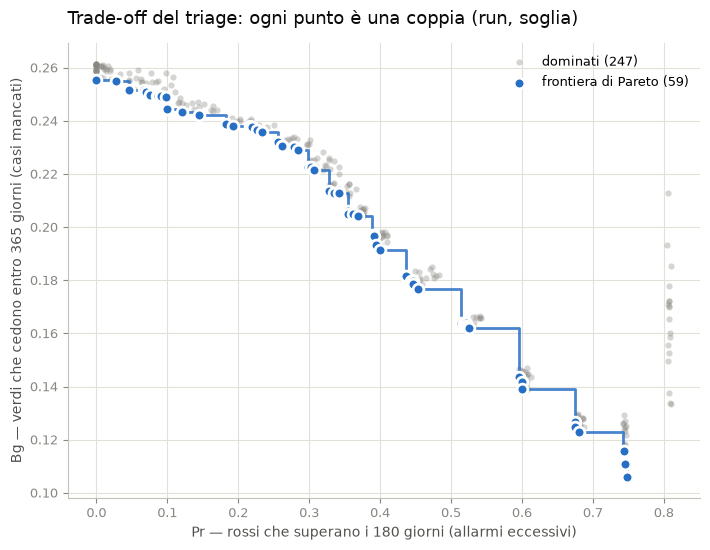

In [4]:
ACCENT, MUTED, GRID, AXIS, INK = "#276fc5", "#898781", "#e1e0d9", "#c3c2b7", "#0b0b0b"

costs = results[["Pr", "Bg"]].to_numpy()


def pareto_mask(costs):
    """True dove nessun altro punto e' <= su entrambi gli assi e < su almeno uno."""
    keep = np.ones(len(costs), dtype=bool)
    for i, c in enumerate(costs):
        dominates = (costs <= c).all(axis=1) & (costs < c).any(axis=1)
        keep[i] = not dominates.any()
    return keep


results["on_frontier"] = pareto_mask(costs)
dominated = results[~results["on_frontier"]]
frontier = results[results["on_frontier"]].sort_values("Pr")

fig, ax = plt.subplots(figsize=(7.2, 5.6))
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

ax.scatter(dominated["Pr"], dominated["Bg"], s=20, c=MUTED, alpha=0.35,
           linewidths=0, label=f"dominati ({len(dominated)})")
# step, non plot: fra due configurazioni non esistono punti intermedi
ax.step(frontier["Pr"], frontier["Bg"], where="post", color=ACCENT, linewidth=2, alpha=0.85, zorder=3)
ax.scatter(frontier["Pr"], frontier["Bg"], s=60, c=ACCENT, edgecolors="white", linewidths=2, zorder=4,
           label=f"frontiera di Pareto ({len(frontier)})")

ax.set_xlabel("Pr — rossi che superano i 180 giorni (allarmi eccessivi)", color="#52514e")
ax.set_ylabel("Bg — verdi che cedono entro 365 giorni (casi mancati)", color="#52514e")
ax.set_title("Trade-off del triage: ogni punto è una coppia (run, soglia)",
             color=INK, fontsize=13, pad=14, loc="left")

for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(AXIS)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, loc="upper right", fontsize=9)
fig.tight_layout()

# la frontiera come tabella, dimensioni dei gruppi incluse
frontier[["run_id", "threshold", "n_reds", "n_yellows", "n_greens", "Pr", "Pg", "Bg"]]

In [5]:
SWEPT = ["max_depth", "min_child_weight", "subsample"]

params = pd.DataFrame(results["params"].tolist(), index=results.index)
export = results.drop(columns=["params", "Model"]).join(params[SWEPT])
export = export.astype({"max_depth": int, "min_child_weight": float, "subsample": float})
# uno zip salvato prima che `save` scrivesse params.json si ricarica senza
# errori e riporta i default della dataclass: 18 run, una configurazione sola
constant = {name for name in SWEPT if export[name].nunique() == 1}
assert not constant, f"non variano fra i run: {sorted(constant)}"

export["threshold"] = export["threshold"].round(2)
export = export[
    ["run_id", *SWEPT, "threshold",
     "n_reds", "n_yellows", "n_greens", "Pr", "Pg", "Bg", "on_frontier"]
]
export

,run_id,max_depth,min_child_weight,subsample,threshold,n_reds,n_yellows,n_greens,Pr,Pg,Bg,on_frontier
0,320c8d4df1df47d3ac5de27e481a9fdf,4,100.0,0.6,0.10,169,297,147829,0.007113,0.739351,0.260649,False
1,320c8d4df1df47d3ac5de27e481a9fdf,4,100.0,0.6,0.15,302,663,147330,0.013107,0.741452,0.258548,False
2,320c8d4df1df47d3ac5de27e481a9fdf,4,100.0,0.6,0.20,440,1362,146493,0.084332,0.745363,0.254637,False
3,320c8d4df1df47d3ac5de27e481a9fdf,4,100.0,0.6,0.25,686,2362,145247,0.087015,0.750534,0.249466,True
4,320c8d4df1df47d3ac5de27e481a9fdf,4,100.0,0.6,0.30,1069,3648,143578,0.121145,0.756698,0.243302,True
...,...,...,...,...,...,...,...,...,...,...,...,...
301,c5aedfd296da440ab4fbb429926a33f7,2,50.0,0.3,0.70,16821,37463,94011,0.534575,0.833991,0.166009,False
302,c5aedfd296da440ab4fbb429926a33f7,2,50.0,0.3,0.75,24530,50219,73546,0.605820,0.855966,0.144034,False
303,c5aedfd296da440ab4fbb429926a33f7,2,50.0,0.3,0.80,37181,61911,49203,0.680599,0.876377,0.123623,False
304,c5aedfd296da440ab4fbb429926a33f7,2,50.0,0.3,0.85,61266,66965,20064,0.747400,0.884030,0.115970,False


In [6]:
export.to_csv("triage_results.csv", index=False)

In [7]:
results

,run_id,threshold,n_reds,n_yellows,n_greens,Pr,Pg,Bg,params,Model,on_frontier
0,320c8d4df1df47d3ac5de27e481a9fdf,0.10,169,297,147829,0.007113,0.739351,0.260649,"{'n_estimators': 800, 'max_depth': 4, 'learnin...",XGBClassifier,False
1,320c8d4df1df47d3ac5de27e481a9fdf,0.15,302,663,147330,0.013107,0.741452,0.258548,"{'n_estimators': 800, 'max_depth': 4, 'learnin...",XGBClassifier,False
2,320c8d4df1df47d3ac5de27e481a9fdf,0.20,440,1362,146493,0.084332,0.745363,0.254637,"{'n_estimators': 800, 'max_depth': 4, 'learnin...",XGBClassifier,False
3,320c8d4df1df47d3ac5de27e481a9fdf,0.25,686,2362,145247,0.087015,0.750534,0.249466,"{'n_estimators': 800, 'max_depth': 4, 'learnin...",XGBClassifier,True
4,320c8d4df1df47d3ac5de27e481a9fdf,0.30,1069,3648,143578,0.121145,0.756698,0.243302,"{'n_estimators': 800, 'max_depth': 4, 'learnin...",XGBClassifier,True
...,...,...,...,...,...,...,...,...,...,...,...
301,c5aedfd296da440ab4fbb429926a33f7,0.70,16821,37463,94011,0.534575,0.833991,0.166009,"{'n_estimators': 800, 'max_depth': 2, 'learnin...",XGBClassifier,False
302,c5aedfd296da440ab4fbb429926a33f7,0.75,24530,50219,73546,0.605820,0.855966,0.144034,"{'n_estimators': 800, 'max_depth': 2, 'learnin...",XGBClassifier,False
303,c5aedfd296da440ab4fbb429926a33f7,0.80,37181,61911,49203,0.680599,0.876377,0.123623,"{'n_estimators': 800, 'max_depth': 2, 'learnin...",XGBClassifier,False
304,c5aedfd296da440ab4fbb429926a33f7,0.85,61266,66965,20064,0.747400,0.884030,0.115970,"{'n_estimators': 800, 'max_depth': 2, 'learnin...",XGBClassifier,False


## 10 punti della frontiera

Dieci punti equispaziati lungo la frontiera, con le tre Kaplan-Meier di ciascuno.

In [8]:
N_POINTS = 10

# equispaziati lungo la frontiera, non lungo Pr: Pr copre [0, 0.81] e Bg [0.11,
# 0.26], quindi senza normalizzare gli assi la distanza sarebbe quasi solo Pr e
# i punti si addenserebbero dove la frontiera corre verticale
front = results[results["on_frontier"]].sort_values("Pr").reset_index(drop=True)
u = (front["Pr"] - front["Pr"].min()) / (front["Pr"].max() - front["Pr"].min())
v = (front["Bg"] - front["Bg"].min()) / (front["Bg"].max() - front["Bg"].min())
arc = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(u), np.diff(v)))])

picked = sorted({int(np.abs(arc - t).argmin()) for t in np.linspace(0, arc[-1], N_POINTS)})
selected = front.loc[picked].reset_index(drop=True)
selected.insert(0, "point", np.arange(1, len(selected) + 1))

# quale formulazione e quale adapter stanno dietro a un run
cfg_of = {rid: cfg for cfg, runs in confs for rid in runs["run_id"]}
tag_of = {rid: tag for _, runs in confs for rid, tag in zip(runs["run_id"], runs["tags.adapter"])}

_frames: dict[int, tuple] = {}
_survs: dict[str, np.ndarray] = {}


def evaluation_set(cfg):
    """Il validation set di quella formulazione, calcolato una volta sola."""
    if id(cfg) not in _frames:
        frame = run_unfitted(cfg)
        tr, te = split_frame(cfg, frame)
        tr, te = run_fitted(cfg, tr, te)
        data = te.data
        _frames[id(cfg)] = (
            ~data["censored"].to_numpy(dtype=bool),
            data["tte"].to_numpy(dtype=np.int32),
            x_y_split(cfg, te)[0],
        )
    return _frames[id(cfg)]


curves = []
for row in selected.itertuples():
    event_r, time_exit_r, X_r = evaluation_set(cfg_of[row.run_id])
    estimator = ModelAdapter.create(tag_of[row.run_id]).load(SAVED_ADAPTERS / row.run_id)

    if isinstance(estimator, XGBoostAdapter):
        if row.run_id not in _survs:
            _survs[row.run_id] = estimator.survival(X_r)
        tte_pred = estimator.predict(X_r, row.threshold, _survs[row.run_id]) * 30
    else:
        tte_pred = estimator.predict(X_r) * 30

    masks = {
        "rosse": tte_pred <= 180,
        "gialle": (tte_pred > 180) & (tte_pred < 365),
        "verdi": tte_pred >= 365,
    }
    curves.append({name: kaplan_meier_estimator(event_r[m], time_exit_r[m]) for name, m in masks.items()})

selected[["Pr", "Bg"]].round(3)

,Pr,Bg
0,0.000,0.255
1,0.100,0.244
2,0.217,0.238
3,0.306,0.221
4,0.368,0.204
5,0.444,0.180
6,0.524,0.162
7,0.600,0.142
8,0.680,0.123
9,0.748,0.106


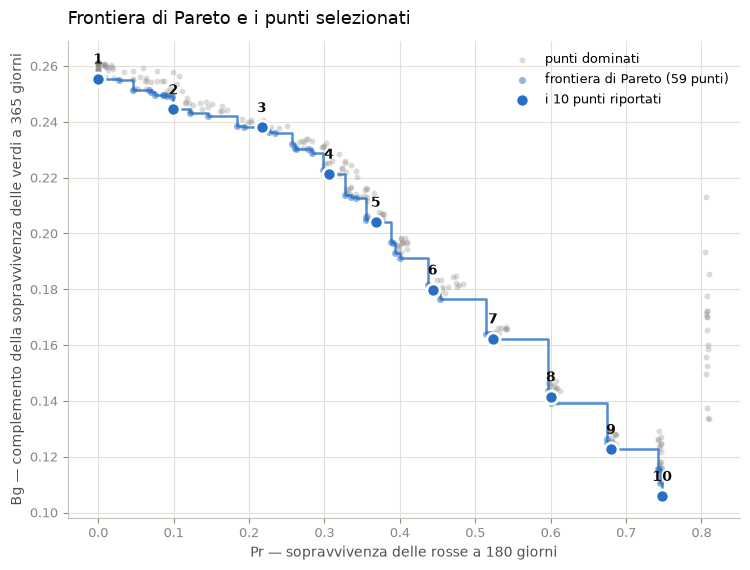

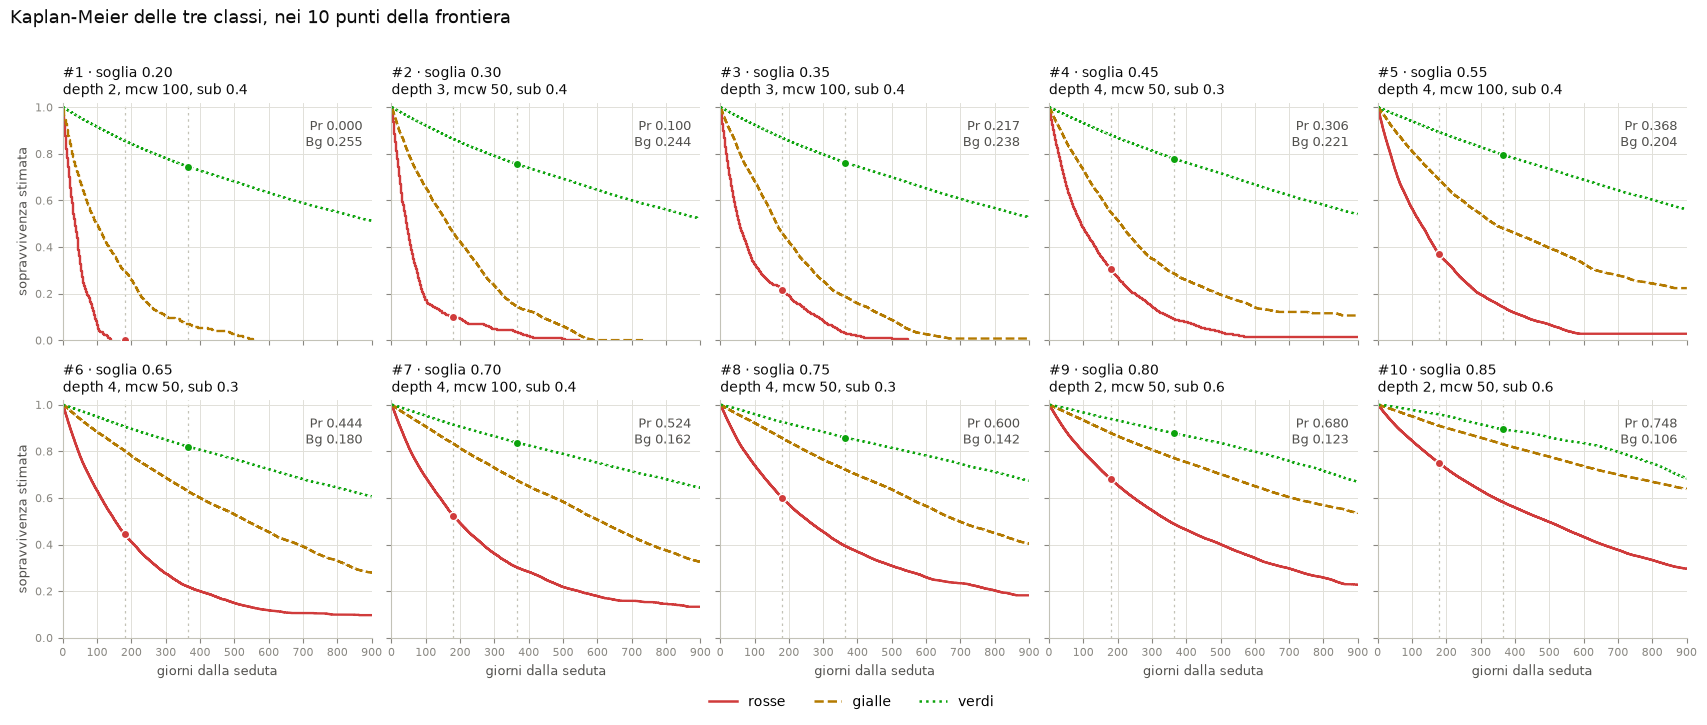

In [9]:
from matplotlib.backends.backend_pdf import PdfPages

# il colore e' semantico ma non porta da solo la distinzione: rosso e verde
# sono la coppia che un daltonismo deutan confonde, quindi ogni curva ha anche
# un tratto diverso
TRIAGE = {"rosse": ("#d03b3b", "-"), "gialle": ("#b47a00", "--"), "verdi": ("#0ca30c", ":")}

fig_front, ax = plt.subplots(figsize=(7.6, 5.8))
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
ax.scatter(results.loc[~results["on_frontier"], "Pr"], results.loc[~results["on_frontier"], "Bg"],
           s=18, c=MUTED, alpha=0.3, linewidths=0, label="punti dominati")
ax.step(front["Pr"], front["Bg"], where="post", color=ACCENT, linewidth=1.8, alpha=0.8, zorder=3)
ax.scatter(front["Pr"], front["Bg"], s=26, c=ACCENT, alpha=0.5, linewidths=0, zorder=4,
           label=f"frontiera di Pareto ({len(front)} punti)")
ax.scatter(selected["Pr"], selected["Bg"], s=90, c=ACCENT, edgecolors="white", linewidths=2, zorder=5,
           label=f"i {len(selected)} punti riportati")
for row in selected.itertuples():
    ax.annotate(str(row.point), (row.Pr, row.Bg), textcoords="offset points", xytext=(0, 11),
                ha="center", fontsize=10, fontweight="bold", color=INK, zorder=6)

ax.set_xlabel("Pr — sopravvivenza delle rosse a 180 giorni", color="#52514e")
ax.set_ylabel("Bg — complemento della sopravvivenza delle verdi a 365 giorni", color="#52514e")
ax.set_title("Frontiera di Pareto e i punti selezionati", color=INK, fontsize=13, pad=12, loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=MUTED, labelsize=9)
ax.legend(frameon=False, loc="upper right", fontsize=9)
fig_front.tight_layout()

rows = int(np.ceil(len(selected) / 5))
fig_km, axes = plt.subplots(rows, 5, figsize=(17, 3.6 * rows), sharex=True, sharey=True)
for ax, (idx, row) in zip(axes.ravel(), enumerate(selected.itertuples())):
    for name, (times, surv) in curves[idx].items():
        color, style = TRIAGE[name]
        ax.step(times, surv, where="post", color=color, linestyle=style, linewidth=1.7, label=name)
    for day in (180, 365):
        ax.axvline(day, color=AXIS, linewidth=0.9, linestyle=(0, (2, 3)), zorder=0)
    ax.plot(180, row.Pr, "o", color=TRIAGE["rosse"][0], markersize=6, markeredgecolor="white", zorder=5)
    ax.plot(365, row.Pg, "o", color=TRIAGE["verdi"][0], markersize=6, markeredgecolor="white", zorder=5)

    p = row.params
    ax.set_title(f"#{row.point} · soglia {row.threshold:.2f}\n"
                 f"depth {p['max_depth']}, mcw {p['min_child_weight']:g}, sub {p['subsample']:g}",
                 fontsize=10, color=INK, loc="left")
    ax.text(0.97, 0.94, f"Pr {row.Pr:.3f}\nBg {row.Bg:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="#52514e", linespacing=1.4)
    ax.set_xlim(0, 900)
    ax.set_ylim(0, 1.02)
    ax.grid(True, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=8)

for ax in axes.ravel()[len(selected):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("giorni dalla seduta", color="#52514e", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("sopravvivenza stimata", color="#52514e", fontsize=9)

handles = [plt.Line2D([], [], color=c, linestyle=s, linewidth=1.8, label=n) for n, (c, s) in TRIAGE.items()]
fig_km.legend(handles=handles, frameon=False, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.01))
fig_km.suptitle("Kaplan-Meier delle tre classi, nei 10 punti della frontiera",
                fontsize=13, color=INK, x=0.005, ha="left")
fig_km.tight_layout(rect=(0, 0.03, 1, 0.97))

# `drop` difensivo: se `results` ha gia' le colonne dello sweep, la join le
# troverebbe doppie e fallirebbe
drop = ["params", "Model"] + [c for c in SWEPT if c in selected.columns]
table = selected.drop(columns=drop).join(
    pd.DataFrame(selected["params"].tolist(), index=selected.index)[SWEPT]
)
table["threshold"] = table["threshold"].round(2)
table = table[["point", "run_id", *SWEPT, "threshold",
               "n_reds", "n_yellows", "n_greens", "Pr", "Pg", "Bg"]]

fig_front.savefig("frontiera_pareto.png", dpi=200, bbox_inches="tight")
fig_km.savefig("km_10_punti.png", dpi=200, bbox_inches="tight")
with PdfPages("triage_figure.pdf") as pdf:
    pdf.savefig(fig_front, bbox_inches="tight")
    pdf.savefig(fig_km, bbox_inches="tight")
table.to_csv("triage_10_punti.csv", index=False)
table.to_latex('triage_10_punti.tex', index=False, float_format="%.2f")

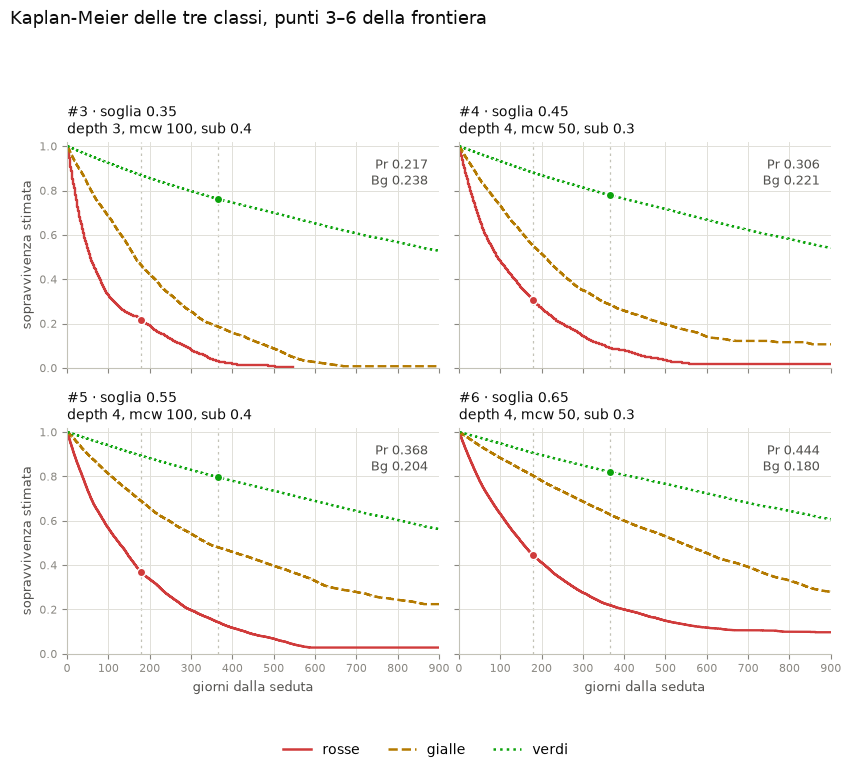

In [24]:
POINTS = [3, 4, 5, 6]

# curves[] e' allineata per posizione a selected, non per la colonna 'point':
# la scorciatoia curves[p-1] vale solo perche' 'point' e' 1..N nello stesso ordine
assert list(selected["point"]) == list(range(1, len(selected) + 1))
subset = selected[selected["point"].isin(POINTS)]
subset_curves = [curves[p - 1] for p in POINTS]

fig_subset, axes = plt.subplots(2, 2, figsize=(8.4, 7.6), sharex=True, sharey=True)
for ax, (idx, row) in zip(axes.ravel(), enumerate(subset.itertuples())):
    for name, (times, surv) in subset_curves[idx].items():
        color, style = TRIAGE[name]
        ax.step(times, surv, where="post", color=color, linestyle=style, linewidth=1.7, label=name)
    for day in (180, 365):
        ax.axvline(day, color=AXIS, linewidth=0.9, linestyle=(0, (2, 3)), zorder=0)
    ax.plot(180, row.Pr, "o", color=TRIAGE["rosse"][0], markersize=6, markeredgecolor="white", zorder=5)
    ax.plot(365, row.Pg, "o", color=TRIAGE["verdi"][0], markersize=6, markeredgecolor="white", zorder=5)

    p = row.params
    ax.set_title(f"#{row.point} · soglia {row.threshold:.2f}\n"
                 f"depth {p['max_depth']}, mcw {p['min_child_weight']:g}, sub {p['subsample']:g}",
                 fontsize=10, color=INK, loc="left")
    ax.text(0.97, 0.94, f"Pr {row.Pr:.3f}\nBg {row.Bg:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="#52514e", linespacing=1.4)
    ax.set_xlim(0, 900)
    ax.set_ylim(0, 1.02)
    ax.grid(True, color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=8)

for ax in axes[-1]:
    ax.set_xlabel("giorni dalla seduta", color="#52514e", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("sopravvivenza stimata", color="#52514e", fontsize=9)

handles = [plt.Line2D([], [], color=c, linestyle=s, linewidth=1.8, label=n) for n, (c, s) in TRIAGE.items()]
fig_subset.legend(handles=handles, frameon=False, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig_subset.suptitle("Kaplan-Meier delle tre classi, punti 3–6 della frontiera",
                     fontsize=13, color=INK, x=0.005, ha="left")
fig_subset.tight_layout(rect=(0, 0.06, 1, 0.92))

fig_subset.savefig("km_punti_3_4_5_6.pdf", bbox_inches="tight")
fig_subset.savefig("km_punti_3_4_5_6.png", dpi=200, bbox_inches="tight")
